In [1]:
%load_ext autoreload
%autoreload 2

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm

module_path = "../eagleeye"
import sys
sys.path.append(module_path)
import EagleEye
from utils_EE import compute_the_null, partitioning_function

from IPython.utils.capture import capture_output
import itertools

In [3]:
colours = {
    "blue": "#6495ec",
    "green": "#93d4c0",
    "pink": "eeadd5",
    "lightblue": "#afbcda",
    "red": "#dc143c",
}

In [10]:
def snr_estimator_Y(result_dict, EE_book):
    over_clusters  = EE_book["Y_OVER_clusters"]
    under_clusters = EE_book["X_OVER_clusters"]

    lenSo = len(np.concatenate([over_clusters[i]['Repechaged'] for i in over_clusters]))
    lenBo = len(np.concatenate([over_clusters[i]['Background'] for i in over_clusters]))
    lenWo = len(np.concatenate([over_clusters[i]['Pruned']     for i in over_clusters]))
    lenWu = len(np.concatenate([under_clusters[i]['Pruned']    for i in under_clusters]))
    n1 = len(result_dict['Upsilon_i_Y'])
    n2 = len(result_dict['Upsilon_i_X'])

    B_hat = lenBo * (n2 - lenWo) / (n1 - lenWu)
    S_hat = lenSo - B_hat

    if B_hat <= 0:
        return np.nan
    return S_hat / np.sqrt(B_hat)

def snr_estimator_X(result_dict, EE_book):
    over_clusters  = EE_book["X_OVER_clusters"]
    under_clusters = EE_book["Y_OVER_clusters"]

    lenSo = len(np.concatenate([over_clusters[i]['Repechaged'] for i in over_clusters]))
    lenBo = len(np.concatenate([over_clusters[i]['Background'] for i in over_clusters]))
    lenWo = len(np.concatenate([over_clusters[i]['Pruned']     for i in over_clusters]))
    lenWu = len(np.concatenate([under_clusters[i]['Pruned']    for i in under_clusters]))
    n1 = len(result_dict['Upsilon_i_X'])
    n2 = len(result_dict['Upsilon_i_Y'])

    B_hat = lenBo * (n2 - lenWo) / (n1 - lenWu)
    S_hat = lenSo - B_hat

    if B_hat <= 0:
        return np.nan
    return S_hat / np.sqrt(B_hat)

def run_one_trial(pool, N_Y, N_X, stats_null, K_M, p_ext, n_jobs):
    idx = np.random.choice(len(pool), N_Y + N_X, replace=False)
    Y = pool[idx[:N_Y]]
    X = pool[idx[N_Y:]]
    with capture_output():
        result_dict, stats_null = EagleEye.Soar(X, Y, K_M=K_M, p_ext=p_ext,
                                        n_jobs=n_jobs, stats_null=stats_null,
                                        result_dict_in={}, do_IDE=True)
        clusters = partitioning_function(X, Y, result_dict, p_ext=p_ext)
        EE_book  = EagleEye.Repechage(X, Y, result_dict, clusters, p_ext=p_ext)
    return snr_estimator_Y(result_dict, EE_book)

In [37]:
results = {}
N_totals = [2_000, 5_000, 10_000, 20_000, 50_000]
K_Ms     = [25, 50, 100, 200]
n_dim    = 2
frac_Y   = 0.2
pool     = np.random.randn(100_000, n_dim)
p_ext=1e-3

for N_total, K_M in itertools.product(N_totals, K_Ms):
    N_Y = int(N_total * frac_Y)
    N_X = N_total - N_Y
    sn  = compute_the_null(p=frac_Y, K_M=K_M)
    snr = np.array([run_one_trial(pool, N_Y, N_X, sn, K_M=K_M, p_ext=p_ext, n_jobs=1)
                    for _ in tqdm(range(200), desc=f"N={N_total} KM={K_M}")])
    fin = snr[np.isfinite(snr)]
    _, p_norm = stats.normaltest(fin) if len(fin) > 8 else (None, np.nan)
    results[(N_total, K_M)] = fin
    print(f"N={N_total:6d}  K_M={K_M:3d}  NaN={np.isnan(snr).mean():.0%}  p_norm={p_norm:.4f}")

N=2000 KM=25: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:07<00:00, 28.08it/s]


N=  2000  K_M= 25  NaN=68%  p_norm=0.0297


N=2000 KM=50: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:07<00:00, 27.88it/s]


N=  2000  K_M= 50  NaN=71%  p_norm=0.4882


N=2000 KM=100: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:09<00:00, 20.46it/s]


...

N= 50000  K_M= 50  NaN=0%  p_norm=0.7144


N=50000 KM=100: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [02:16<00:00,  1.47it/s]


N= 50000  K_M=100  NaN=0%  p_norm=0.0483


N=50000 KM=200: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [04:28<00:00,  1.34s/it]

N= 50000  K_M=200  NaN=0%  p_norm=0.6012


In [38]:
for k, v in results.items():
    _, p_norm = stats.normaltest(v)
    print(k, ": ", p_norm)

(2000, 25) :  0.029726173433875003
(2000, 50) :  0.48822761960433936
(2000, 100) :  0.38347215029077
(2000, 200) :  0.024307484706527032
(5000, 25) :  0.14645022537621477
(5000, 50) :  0.32253452393111876
(5000, 100) :  0.1419667011466808
(5000, 200) :  1.1933140687401708e-07
(10000, 25) :  0.04241902580765111
(10000, 50) :  0.37708568791886204
(10000, 100) :  0.00028295322575488664
(10000, 200) :  0.019125371509563404
(20000, 25) :  3.3931659443097985e-05
(20000, 50) :  0.5450346349531047
(20000, 100) :  0.7635092609023699
(20000, 200) :  0.9293166075281654
(50000, 25) :  0.21735580544051428
(50000, 50) :  0.714374299212617
(50000, 100) :  0.04834015471465124
(50000, 200) :  0.601244365557047


In [39]:
def biplot_normal(snr_arr, N_tot, K_M):
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    s, p_norm = stats.normaltest(snr_arr)
    axes[0].hist(snr_arr, bins=30, density=True, color=colours["blue"], label=f"N={N_tot}, K_M={K_M}")
    x = np.linspace(np.nanmin(snr_arr), np.nanmax(snr_arr), 300)
    mu, sigma = np.nanmean(snr_arr), np.nanstd(snr_arr)
    axes[0].plot(x, stats.norm.pdf(x, mu, sigma), "k-", label=f"p-val={p_norm:.3f}")
    axes[0].set_xlabel(r"$\Lambda_\alpha$")
    
    stats.probplot(snr_arr, dist="norm", plot=axes[1])
    axes[1].set_title("")
    
    axes[0].legend()
    plt.tight_layout()

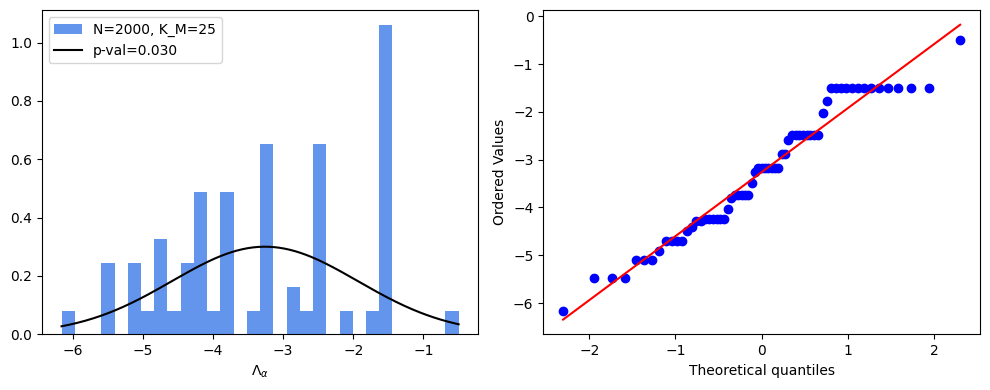

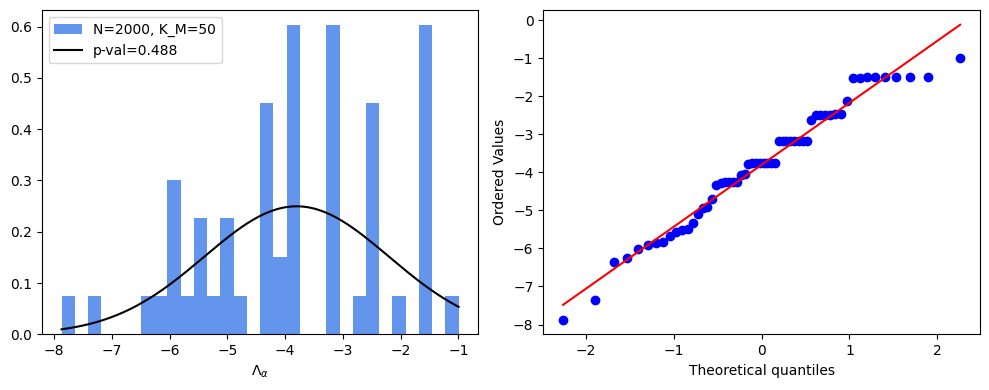

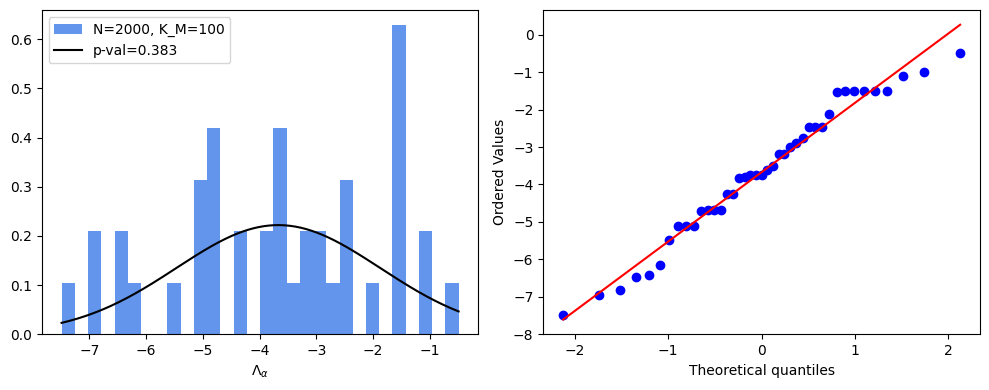

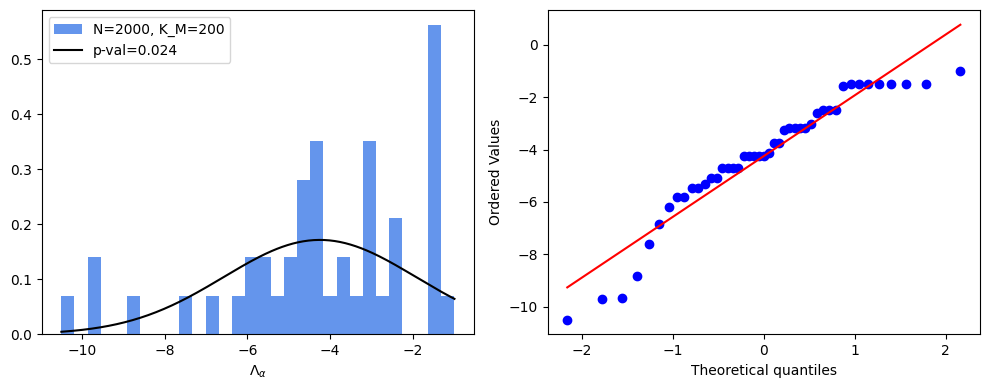

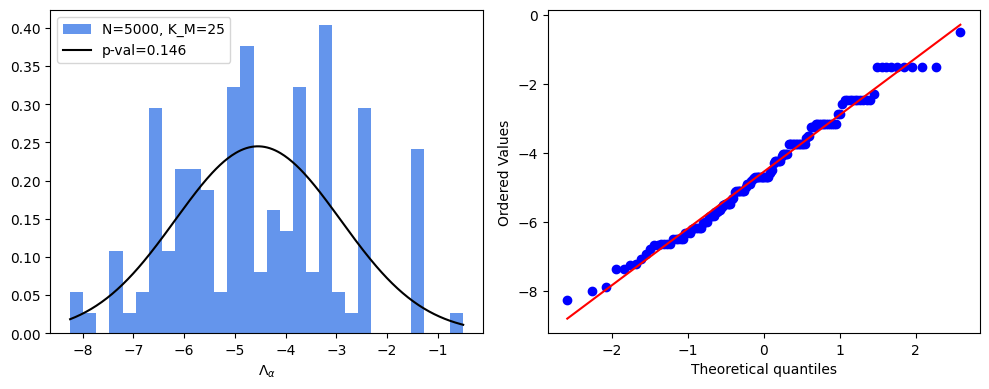

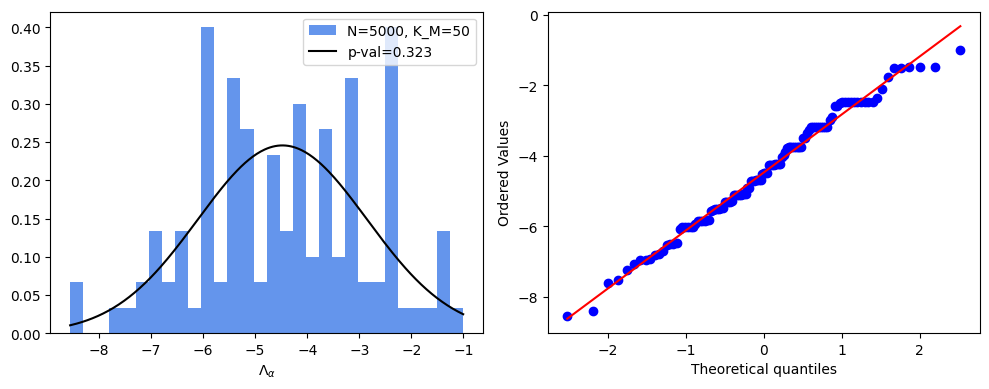

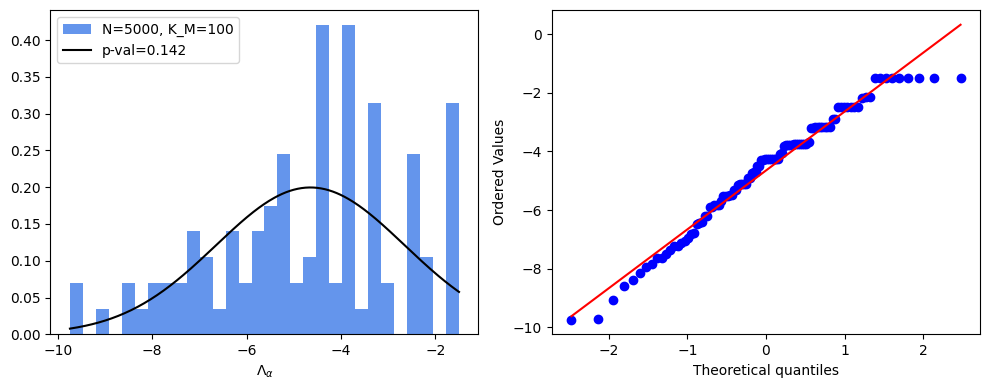

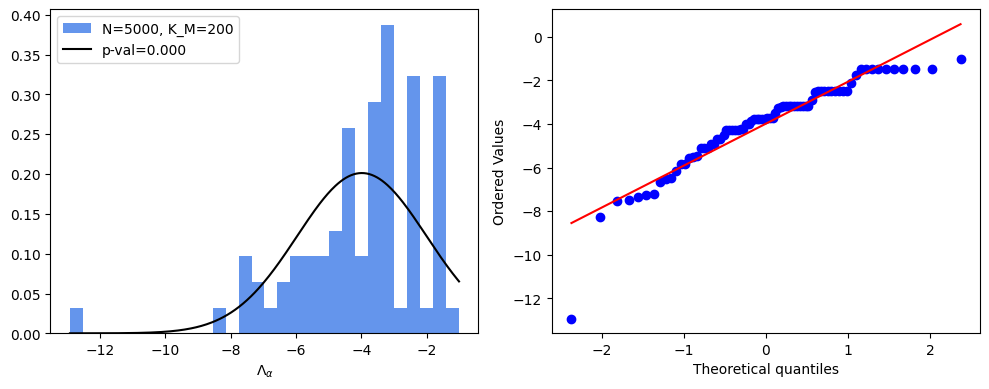

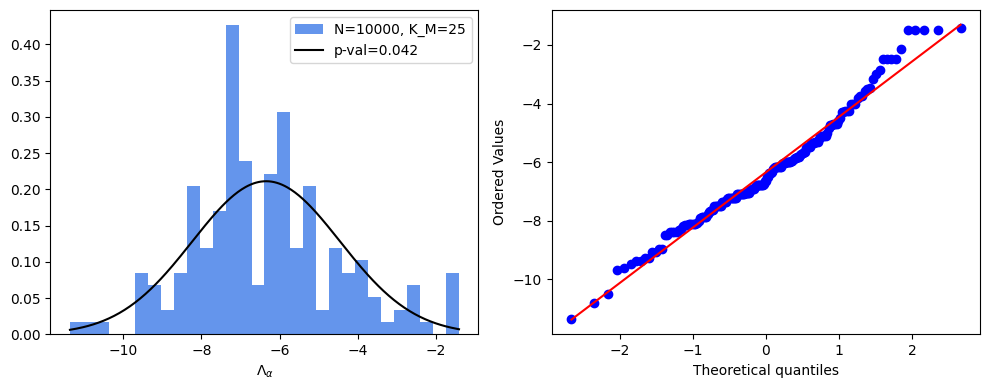

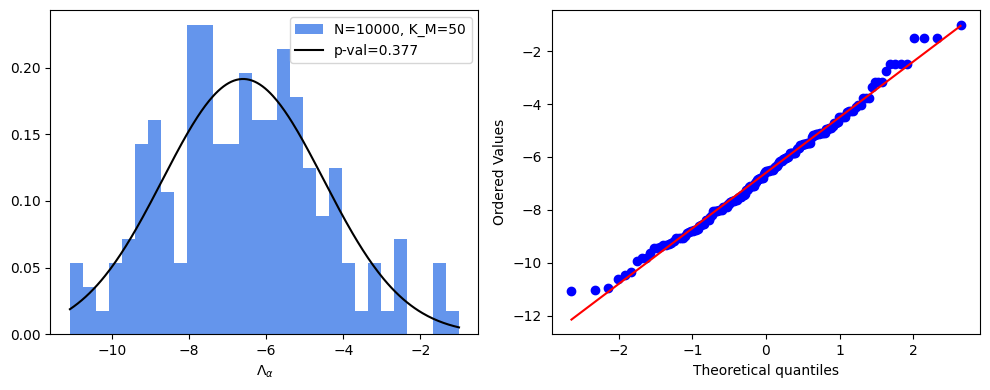

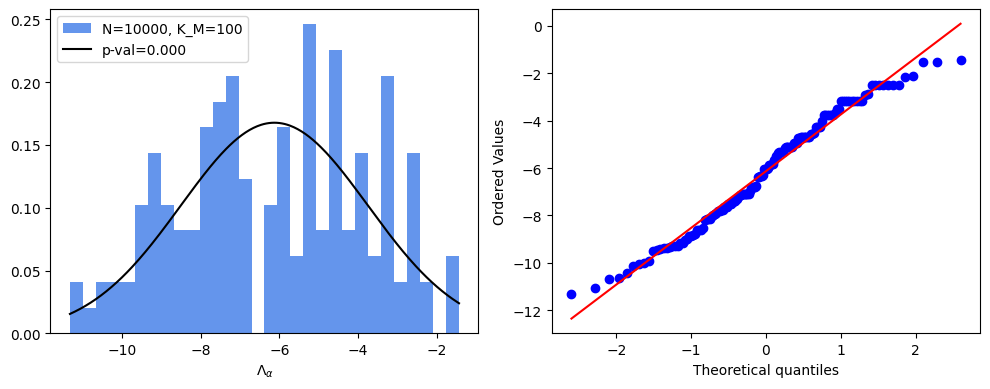

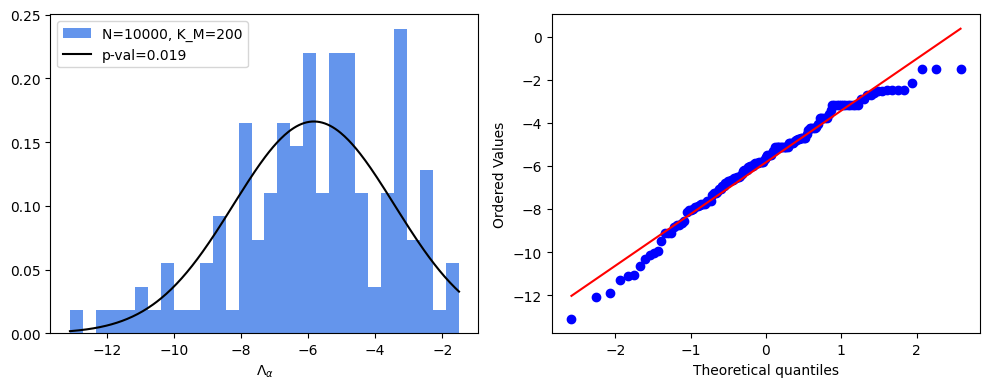

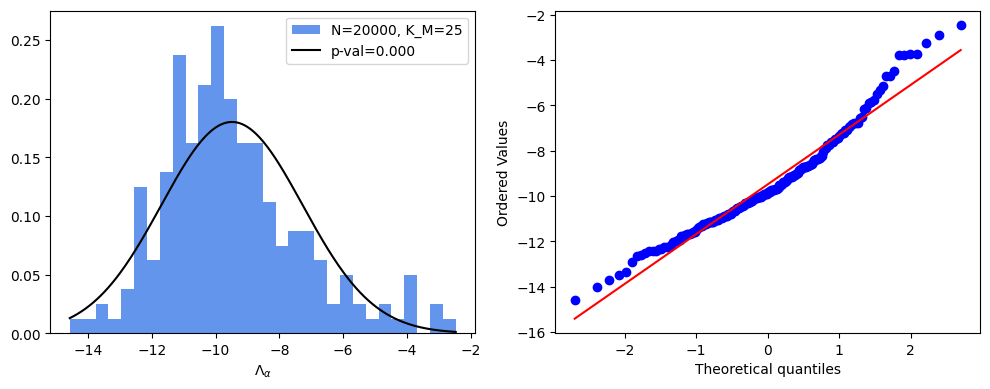

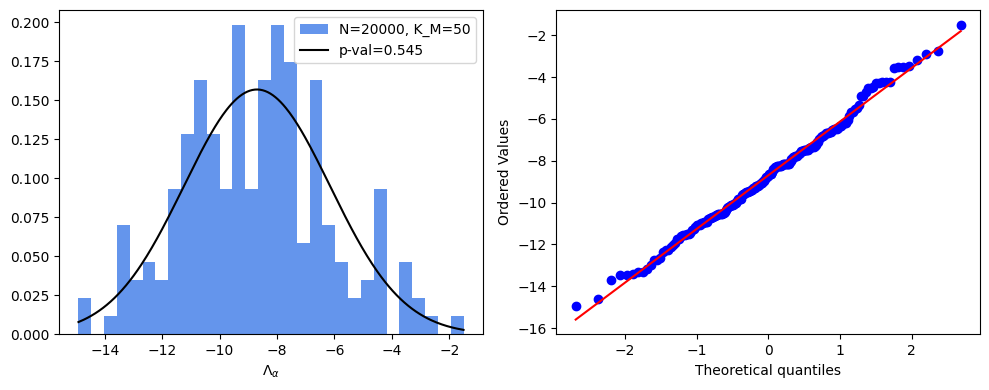

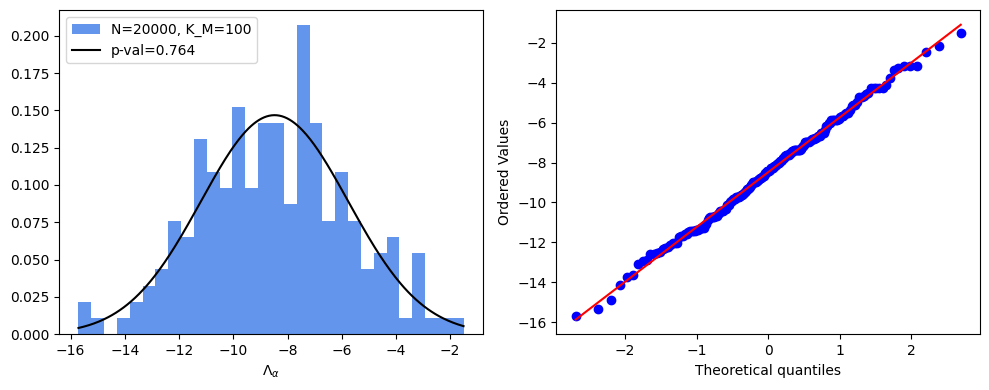

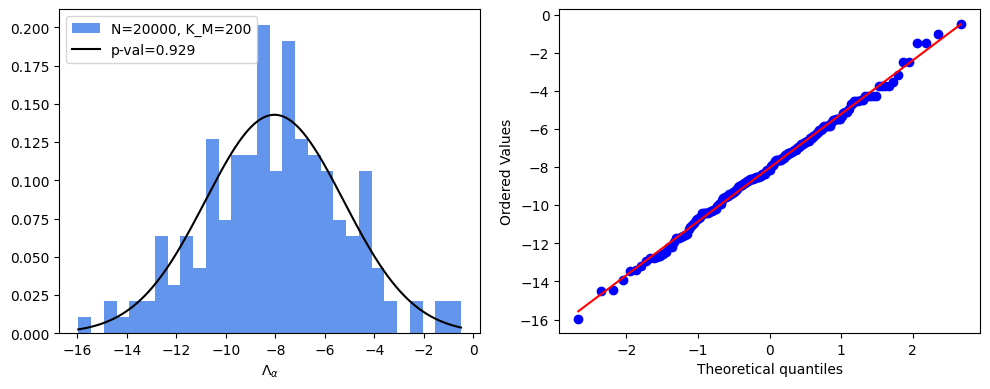

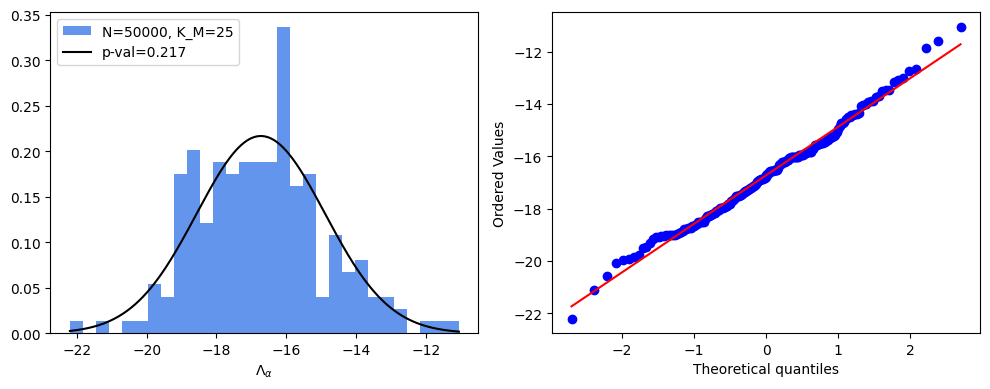

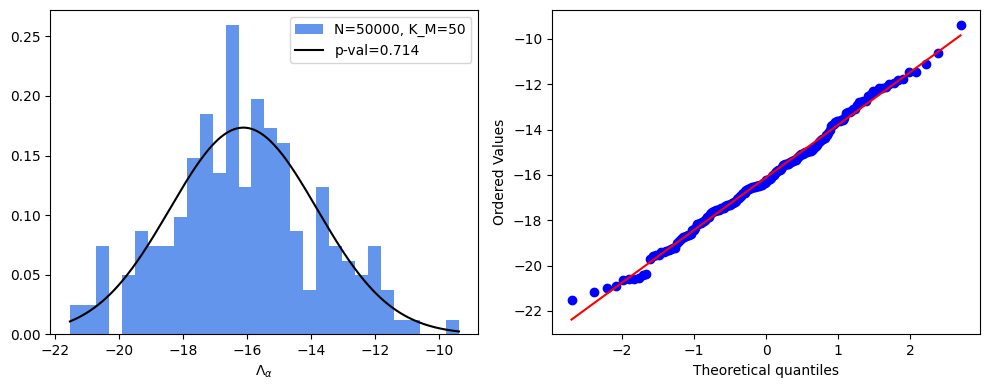

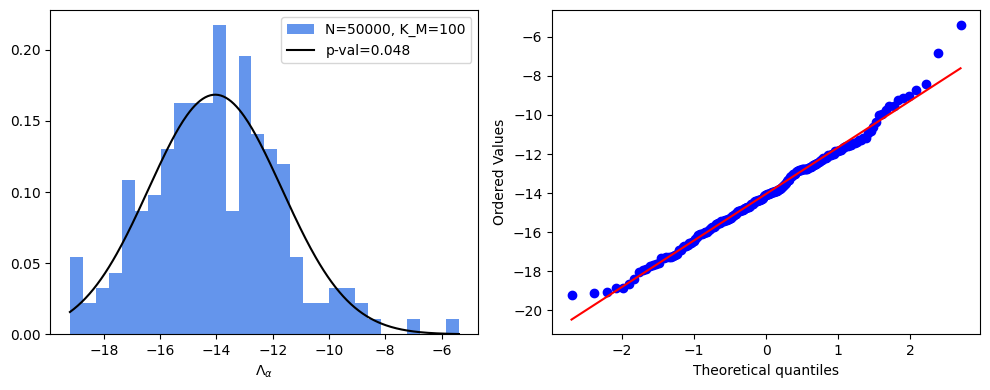

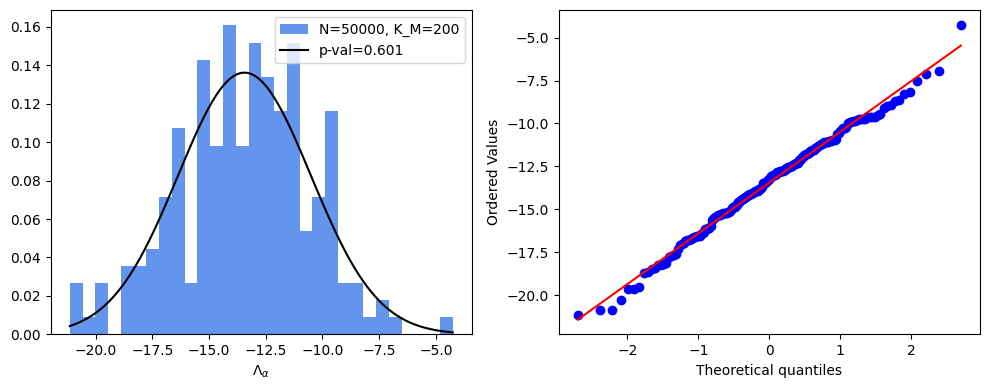

In [40]:
for k, v in results.items():
    biplot_normal(v, k[0], k[1])